<a href="https://colab.research.google.com/github/TheJcabal/TheJcabal/blob/copilot%2Fcreate-python-projects/bfs_dfs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Un ejmplo sencillo de Busqueda por anchura (BFS) y busqueda profunda (DFS)

Secuencia BFS: ['A', 'B', 'C', 'D', 'E', 'F', 'G']
Secuencia DFS: ['A', 'B', 'D', 'E', 'C', 'F', 'G']


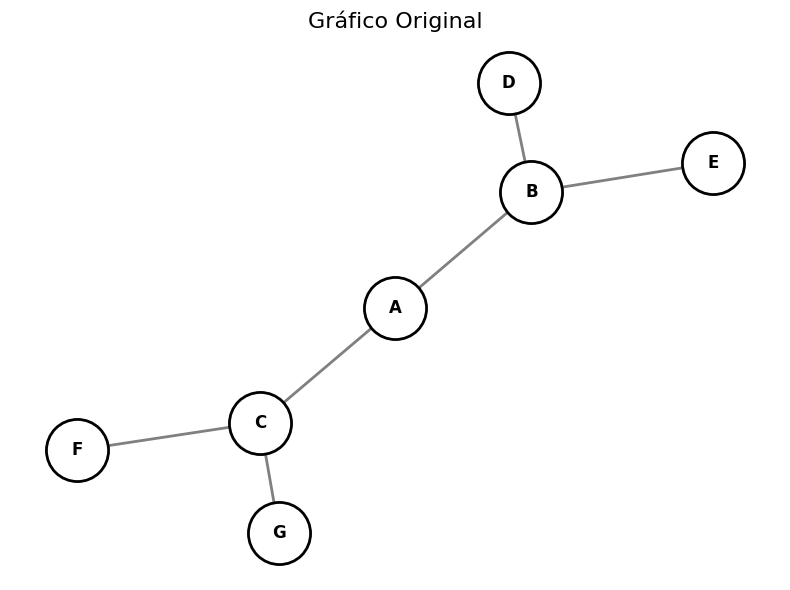

ValueError: Unable to determine Axes to steal space for Colorbar. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.

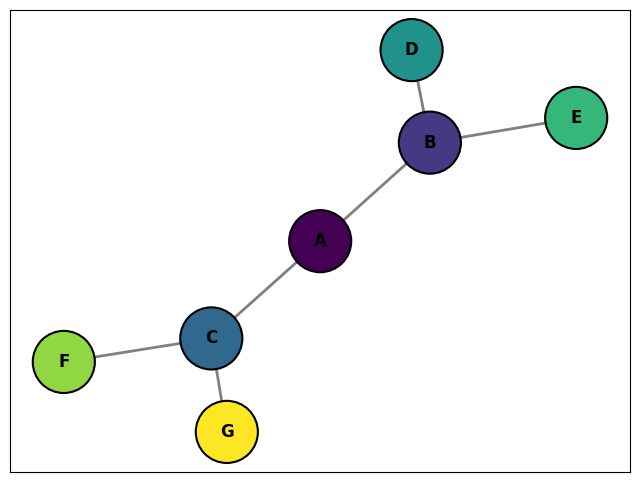

In [ ]:
# ============================================================
# IMPLEMENTACIÓN DE BFS Y DFS CON VISUALIZACIÓN CORREGIDA
# Autor: Jheison Cabal
# Lenguaje: Python
# Librerías: NetworkX, Matplotlib
# ============================================================

import networkx as nx
import matplotlib.pyplot as plt
from collections import deque

# ----------------------------
# 1. CREAR EL GRAFO
# ----------------------------
G = nx.Graph()
edges = [
    ('A','B'),
    ('A','C'),
    ('B','D'),
    ('B','E'),
    ('C','F'),
    ('C','G')
]
G.add_edges_from(edges)

# Generar la posición de los nodos una vez para usarla en todos los gráficos
pos = nx.spring_layout(G, seed=42)

# ----------------------------
# 2. ALGORITMO BFS (Orden de visita)
# ----------------------------
def bfs_with_order(graph, start):
    """Retorna la lista de nodos en el orden exacto que fueron visitados"""
    visited = []
    queue = deque([start])

    # Usamos un set para verificar rápidamente si ya está en la cola
    in_queue = {start}

    while queue:
        node = queue.popleft()

        # Se añade al registro de visitas (en el orden de salida de la cola)
        visited.append(node)

        # Verificar vecinos no visitados
        for neighbor in graph.neighbors(node):
            if neighbor not in in_queue and neighbor not in visited:
                in_queue.add(neighbor)
                queue.append(neighbor)

    return visited

# ----------------------------
# 3. ALGORITMO DFS (Orden de visita)
# ----------------------------
def dfs_with_order(graph, start, visited=None, order=None):
    """Retorna la lista de nodos en el orden exacto que fueron visitados"""
    if visited is None:
        visited = []
        order = []

    visited.append(start)
    order.append(start)

    for neighbor in graph.neighbors(start):
        if neighbor not in visited:
            dfs_with_order(graph, neighbor, visited, order)

    return order

# ----------------------------
# 4. EJECUTAR ALGORITMOS
# ----------------------------
bfs_sequence = bfs_with_order(G, 'A')
dfs_sequence = dfs_with_order(G, 'A')

print("Secuencia BFS:", bfs_sequence)
print("Secuencia DFS:", dfs_sequence)

# ----------------------------
# 5. FUNCIÓN AUXILIAR PARA COLOREAR POR ORDEN
# ----------------------------
def get_node_colors_by_order(nodes_list):
    """Convierte la secuencia de nodos en colores basados en su índice (0, 1, 2...)"""
    node_colors = {}
    for index, node in enumerate(nodes_list):
        node_colors[node] = index

    # Mapeo para todo el grafo (los visitados tendrán su orden, los otros -1)
    final_colors = []
    for node in G.nodes():
        final_colors.append(node_colors.get(node, -1))

    return final_colors

# ----------------------------
# 6. DIBUJAR EL GRAFO ORIGINAL
# ----------------------------
plt.figure(figsize=(8, 6))
nx.draw_networkx_nodes(G, pos, node_size=2000, node_color='white', edgecolors='black', linewidths=2)
nx.draw_networkx_edges(G, pos, width=2, edge_color='gray', arrows=True) # Arrows helps see directionality visually
nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')

plt.title("Gráfico Original", fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

# ----------------------------
# 7. VISUALIZAR RECORRIDO BFS (Calentamiento de colores)
# ----------------------------
plt.figure(figsize=(8, 6))
color_map = get_node_colors_by_order(bfs_sequence)
# Usamos 'viridis' para visualizar el progreso del tiempo (azul -> amarillo)
nx.draw_networkx_nodes(G, pos, node_size=2000, node_color=color_map,
                       cmap=plt.cm.viridis, edgecolors='black', linewidths=1.5)
nx.draw_networkx_edges(G, pos, width=2, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')

cbar = plt.colorbar(plt.cm.ScalarMappable(cmap=plt.cm.viridis), label="Orden de Visita")
plt.title("Algoritmo BFS (Por Capas)", fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

# ----------------------------
# 8. VISUALIZAR RECORRIDO DFS (Profundización de colores)
# ----------------------------
plt.figure(figsize=(8, 6))
color_map = get_node_colors_by_order(dfs_sequence)
# Usamos 'coolwarm' para contrastar inicio vs fin
nx.draw_networkx_nodes(G, pos, node_size=2000, node_color=color_map,
                       cmap=plt.cm.coolwarm, edgecolors='black', linewidths=1.5)
nx.draw_networkx_edges(G, pos, width=2, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')

cbar = plt.colorbar(plt.cm.ScalarMappable(cmap=plt.cm.coolwarm), label="Orden de Visita")
plt.title("Algoritmo DFS (En Profundidad)", fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()